# WaveHand Single-File Processing Inspection

这个 notebook 用来先在单个 WaveHand `calibrated_imu_*.csv` 上验证处理流程，暂不写入正式 `/Volumes/Felix_Backups/Processed2`。

检查重点：

- 读取 `IMU_Ring` / `IMU_Wrist` 的 calibrated CSV
- 确认加速度已经是 `m/s^2`
- 将角速度从 `deg/s` 转成 `rad/s`
- 统计原始帧率和每秒 raw frame count
- 用 `120 raw frames/sec` 做质量检查
- 一阶线性插值到 `150 Hz`
- 生成 `10s` 和 `1024f` 两种样例片段
- 保存并重新读取 `.npz`，检查 shape、dtype、time_ms 和可视化波形

默认样例是 group 1 的 ring 文件。你可以修改 `SAMPLE_GROUP`、`SAMPLE_DEVICE`、`SAMPLE_FILE` 来检查其他文件。

## 0. Imports And Config

`OUTPUT_ROOT` 只用于 notebook 调试输出，不是正式 processed 目录。正式全量处理脚本确认后再写入 `/Volumes/Felix_Backups/Processed2`。

In [1]:
from pathlib import Path
import csv
import json
import math
from collections import Counter, defaultdict
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt

RAW_ROOT = Path('/Users/zixuanwang/Desktop/HiSync_publish_anonymous')
OUTPUT_ROOT = Path('/Users/zixuanwang/Code/research/Dino_Data_Process/WaveHand/inspect_outputs')
SOURCE = 'WaveHand'

TARGET_FREQ = 150.0
TARGET_DT_MS = 1000.0 / TARGET_FREQ
RAW_MIN_HZ = 120

DEVICE_DIRS = {
    'ring': 'IMU_Ring',
    'watch': 'IMU_Wrist',
}

# Modify these three values to inspect another file.
SAMPLE_GROUP = 1
SAMPLE_DEVICE = 'ring'  # 'ring' or 'watch'
SAMPLE_FILE = None      # None means first calibrated_imu_*.csv in that group/device.

REQUIRED_COLUMNS = [
    'deviceTimestamp',
    'accel_with_gravity_x',
    'accel_with_gravity_y',
    'accel_with_gravity_z',
    'gyro_x',
    'gyro_y',
    'gyro_z',
]

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
(OUTPUT_ROOT / 'figures').mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['savefig.bbox'] = 'tight'

print('RAW_ROOT exists:', RAW_ROOT.exists())
print('OUTPUT_ROOT:', OUTPUT_ROOT)
print('TARGET_FREQ:', TARGET_FREQ, 'Hz')
print('TARGET_DT_MS:', TARGET_DT_MS, 'ms')
print('RAW_MIN_HZ:', RAW_MIN_HZ)

RAW_ROOT exists: True
OUTPUT_ROOT: /Users/zixuanwang/Code/research/Dino_Data_Process/WaveHand/inspect_outputs
TARGET_FREQ: 150.0 Hz
TARGET_DT_MS: 6.666666666666667 ms
RAW_MIN_HZ: 120


## 1. Discover WaveHand Files

只处理 `IMU_Ring` 和 `IMU_Wrist` 下的 `calibrated_imu_*.csv`。`IMU_Palm` 暂不进入本次 processed 数据。

In [2]:
def discover_wavehand_files(raw_root: Path) -> list[dict]:
    """Return calibrated ring/watch CSV files with group and device metadata."""

    records = []
    group_dirs = sorted(
        [p for p in raw_root.iterdir() if p.is_dir() and p.name.isdigit()],
        key=lambda p: int(p.name),
    )
    for group_dir in group_dirs:
        group = int(group_dir.name)
        for device, imu_dir in DEVICE_DIRS.items():
            device_dir = group_dir / 'IMU' / imu_dir
            if not device_dir.exists():
                continue
            for path in sorted(device_dir.glob('calibrated_imu_*.csv')):
                records.append({
                    'group': group,
                    'device': device,
                    'path': path,
                    'relative_path': path.relative_to(raw_root),
                })
    return records

files = discover_wavehand_files(RAW_ROOT)
by_device = Counter(r['device'] for r in files)
groups = sorted(set(r['group'] for r in files))
print('calibrated ring/watch files:', len(files))
print('groups:', groups)
print('by device:', dict(by_device))
print('first 8 files:')
for r in files[:8]:
    print(' ', r['group'], r['device'], r['relative_path'])

candidates = [
    r for r in files
    if r['group'] == SAMPLE_GROUP and r['device'] == SAMPLE_DEVICE and (SAMPLE_FILE is None or r['path'].name == SAMPLE_FILE)
]
if not candidates:
    raise FileNotFoundError(f'No file for group={SAMPLE_GROUP}, device={SAMPLE_DEVICE}, file={SAMPLE_FILE}')

sample = candidates[0]
sample_path = sample['path']
print('\nselected sample:', sample['relative_path'])

calibrated ring/watch files: 53
groups: [1, 2, 3, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
by device: {'ring': 25, 'watch': 28}
first 8 files:
  1 ring 1/IMU/IMU_Ring/calibrated_imu_20250726_132741.csv
  1 ring 1/IMU/IMU_Ring/calibrated_imu_20250726_135823.csv
  1 watch 1/IMU/IMU_Wrist/calibrated_imu_20250726_132741.csv
  1 watch 1/IMU/IMU_Wrist/calibrated_imu_20250726_135823.csv
  2 ring 2/IMU/IMU_Ring/calibrated_imu_20250726_152756.csv
  2 ring 2/IMU/IMU_Ring/calibrated_imu_20250726_154122.csv
  2 watch 2/IMU/IMU_Wrist/calibrated_imu_20250726_152756.csv
  2 watch 2/IMU/IMU_Wrist/calibrated_imu_20250726_154122.csv

selected sample: 1/IMU/IMU_Ring/calibrated_imu_20250726_132741.csv


## 2. Read One CSV

读取后会做基础清洗：

- 丢弃任一必需字段不是有限数值的行
- 保留原始顺序下的非正时间间隔计数，便于发现采集异常
- 按 `deviceTimestamp` 稳定排序
- 重复时间戳只保留第一条
- 将时间轴转换成从 `0` 开始的 `time_ms`
- 加速度不做单位换算，因为 `accel_with_gravity_*` 已经是 `m/s^2`
- 角速度从 `deg/s` 转成 `rad/s`

In [3]:
def _parse_float(row: dict, column: str) -> Optional[float]:
    try:
        value = float(row[column])
    except Exception:
        return None
    if not math.isfinite(value):
        return None
    return value


def read_wavehand_csv(path: Path) -> dict:
    """Read one WaveHand calibrated CSV and return clean arrays in standard units."""

    columns = {name: [] for name in REQUIRED_COLUMNS}
    total_rows = 0
    bad_rows = 0

    with path.open('r', encoding='utf-8-sig', newline='') as f:
        reader = csv.DictReader(f)
        missing = [name for name in REQUIRED_COLUMNS if name not in (reader.fieldnames or [])]
        if missing:
            raise ValueError(f'missing columns: {missing}')

        for row in reader:
            total_rows += 1
            values = [_parse_float(row, name) for name in REQUIRED_COLUMNS]
            if any(v is None for v in values):
                bad_rows += 1
                continue
            for name, value in zip(REQUIRED_COLUMNS, values):
                columns[name].append(value)

    if len(columns['deviceTimestamp']) < 2:
        raise ValueError('too few finite rows')

    original_t = np.asarray(columns['deviceTimestamp'], dtype=np.float64)
    original_dt = np.diff(original_t)
    nonpositive_dt_original_order = int(np.sum(original_dt <= 0))

    acc = np.column_stack([
        columns['accel_with_gravity_x'],
        columns['accel_with_gravity_y'],
        columns['accel_with_gravity_z'],
    ]).astype(np.float64)

    gyro_deg_s = np.column_stack([
        columns['gyro_x'],
        columns['gyro_y'],
        columns['gyro_z'],
    ]).astype(np.float64)
    gyro_rad_s = gyro_deg_s * np.pi / 180.0

    order = np.argsort(original_t, kind='stable')
    sorted_t = original_t[order]
    sorted_acc = acc[order]
    sorted_gyro = gyro_rad_s[order]

    _, first_idx = np.unique(sorted_t, return_index=True)
    keep = np.sort(first_idx)
    duplicate_timestamps = int(len(sorted_t) - len(keep))

    clean_t = sorted_t[keep]
    clean_acc = sorted_acc[keep]
    clean_gyro = sorted_gyro[keep]
    clean_t = clean_t - clean_t[0]

    return {
        'path': path,
        'time_ms': clean_t,
        'acc': clean_acc,
        'gyro': clean_gyro,
        'stats': {
            'total_rows': total_rows,
            'bad_rows': bad_rows,
            'finite_rows': int(len(original_t)),
            'clean_rows': int(len(clean_t)),
            'duplicate_timestamps': duplicate_timestamps,
            'nonpositive_dt_original_order': nonpositive_dt_original_order,
        },
    }

raw = read_wavehand_csv(sample_path)
print(json.dumps(raw['stats'], indent=2))
print('time range ms:', float(raw['time_ms'][0]), '->', float(raw['time_ms'][-1]))
print('acc shape:', raw['acc'].shape, 'gyro shape:', raw['gyro'].shape)
print('first acc row m/s^2:', raw['acc'][0])
print('first gyro row rad/s:', raw['gyro'][0])

{
  "total_rows": 316891,
  "bad_rows": 0,
  "finite_rows": 316891,
  "clean_rows": 316891,
  "duplicate_timestamps": 0,
  "nonpositive_dt_original_order": 0
}
time range ms: 0.0 -> 1619925.0
acc shape: (316891, 3) gyro shape: (316891, 3)
first acc row m/s^2: [9.67684112 0.05189652 1.48092049]
first gyro row rad/s: [-0.02343576  0.01278318 -0.00213052]


## 3. Raw Timeline Quality

这里检查原始时间轴：平均帧率、相邻帧间隔分布，以及每秒 raw frame count。WaveHand 的质量阈值是每秒至少 `120` 个原始样本。

In [4]:
def percentile(values: np.ndarray, p: float) -> float:
    if len(values) == 0:
        return float('nan')
    return float(np.percentile(values, p))


def timeline_summary(time_ms: np.ndarray) -> dict:
    """Summarize sampling interval and average sampling rate."""

    dt = np.diff(time_ms)
    pos_dt = dt[dt > 0]
    rounded_dt = np.round(pos_dt, 3)
    dt_mode = Counter(rounded_dt.tolist()).most_common(1)[0][0] if len(rounded_dt) else float('nan')
    duration_sec = float((time_ms[-1] - time_ms[0]) / 1000.0)
    avg_hz = float((len(time_ms) - 1) / duration_sec) if duration_sec > 0 else float('nan')
    return {
        'duration_sec': duration_sec,
        'avg_hz': avg_hz,
        'median_dt_ms': float(np.median(pos_dt)) if len(pos_dt) else float('nan'),
        'dt_mode_ms': float(dt_mode),
        'min_dt_ms': float(np.min(pos_dt)) if len(pos_dt) else float('nan'),
        'p95_dt_ms': percentile(pos_dt, 95),
        'max_dt_ms': float(np.max(pos_dt)) if len(pos_dt) else float('nan'),
        'nonpositive_dt_after_clean': int(np.sum(dt <= 0)),
    }


def build_quality_bins(time_ms: np.ndarray, min_hz: int = RAW_MIN_HZ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Count raw samples in 1-second bins and mark bins meeting min_hz."""

    end = math.ceil(float(time_ms[-1]) / 1000.0) * 1000.0
    bins = np.arange(0.0, end + 1000.0, 1000.0)
    counts, _ = np.histogram(time_ms, bins=bins)
    valid = counts >= min_hz
    return bins, counts, valid

summary = timeline_summary(raw['time_ms'])
bins, raw_counts, raw_valid = build_quality_bins(raw['time_ms'])
print(json.dumps({k: round(v, 6) if isinstance(v, float) else v for k, v in summary.items()}, indent=2))
print('seconds:', len(raw_counts))
print('valid seconds:', int(raw_valid.sum()))
print('invalid seconds:', int((~raw_valid).sum()))
print('valid ratio:', float(raw_valid.mean()))
print('whole-file avg_hz >= 120:', summary['avg_hz'] >= RAW_MIN_HZ)
print('first 20 per-second counts:', raw_counts[:20].tolist())

{
  "duration_sec": 1619.925,
  "avg_hz": 195.620168,
  "median_dt_ms": 5.0,
  "dt_mode_ms": 5.0,
  "min_dt_ms": 5.0,
  "p95_dt_ms": 5.0,
  "max_dt_ms": 220.0,
  "nonpositive_dt_after_clean": 0
}
seconds: 1620
valid seconds: 1601
invalid seconds: 19
valid ratio: 0.9882716049382716
whole-file avg_hz >= 120: True
first 20 per-second counts: [200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 199, 200]


saved: /Users/zixuanwang/Code/research/Dino_Data_Process/WaveHand/inspect_outputs/figures/raw_quality.svg


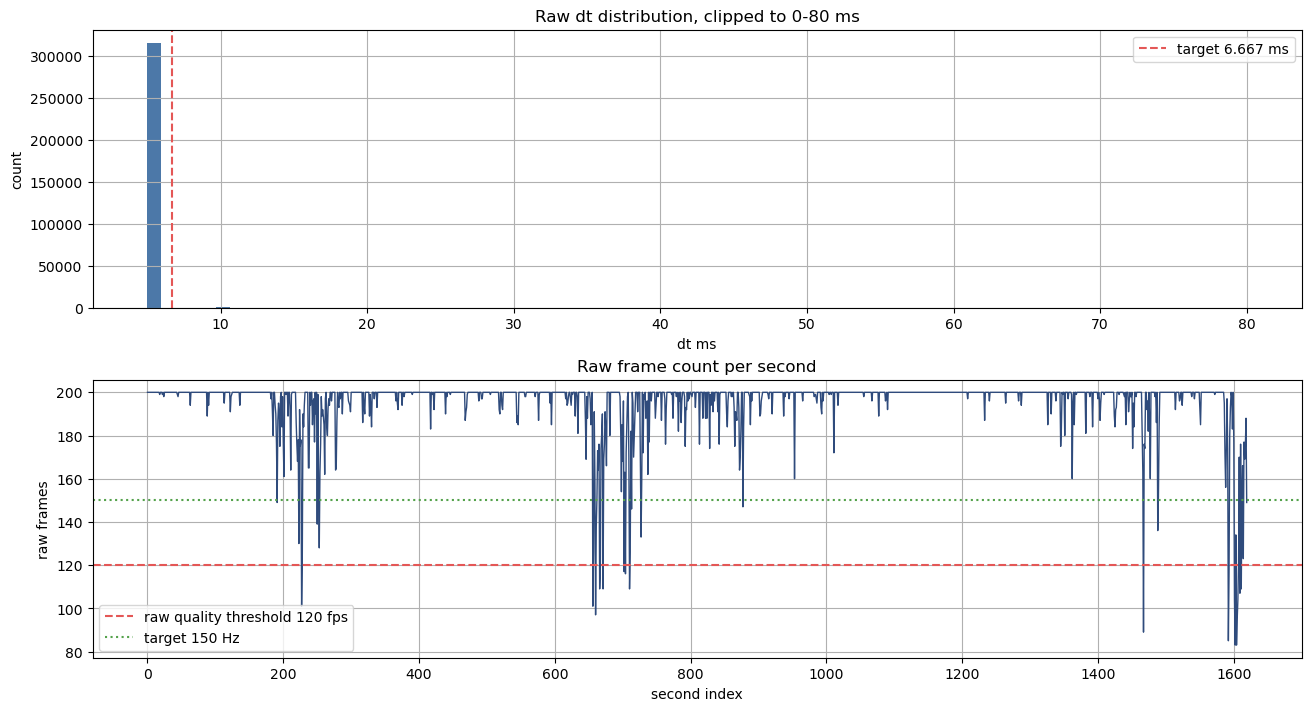

In [5]:
dt = np.diff(raw['time_ms'])
pos_dt = dt[dt > 0]
seconds = np.arange(len(raw_counts))

fig, axes = plt.subplots(2, 1, figsize=(13, 7), constrained_layout=True)
axes[0].hist(np.clip(pos_dt, 0, 80), bins=80, color='#4C78A8')
axes[0].axvline(TARGET_DT_MS, color='#E45756', linestyle='--', label=f'target {TARGET_DT_MS:.3f} ms')
axes[0].set_title('Raw dt distribution, clipped to 0-80 ms')
axes[0].set_xlabel('dt ms')
axes[0].set_ylabel('count')
axes[0].legend()

axes[1].plot(seconds, raw_counts, linewidth=1.0, color='#2F4B7C')
axes[1].axhline(RAW_MIN_HZ, color='#E45756', linestyle='--', label='raw quality threshold 120 fps')
axes[1].axhline(TARGET_FREQ, color='#54A24B', linestyle=':', label='target 150 Hz')
axes[1].set_title('Raw frame count per second')
axes[1].set_xlabel('second index')
axes[1].set_ylabel('raw frames')
axes[1].legend()

fig_path = OUTPUT_ROOT / 'figures' / 'raw_quality.svg'
fig.savefig(fig_path)
print('saved:', fig_path)
plt.show()

## 4. Resample To 150 Hz

使用一阶线性插值。目标网格只覆盖原始时间范围内部，不做 extrapolation。

In [6]:
def interpolate_columns(time_ms: np.ndarray, values: np.ndarray, target_t: np.ndarray) -> np.ndarray:
    """Linearly interpolate each signal column to target_t."""

    out = np.empty((len(target_t), values.shape[1]), dtype=np.float64)
    for axis in range(values.shape[1]):
        out[:, axis] = np.interp(target_t, time_ms, values[:, axis])
    return out


def resample_to_target(data: dict, target_freq: float = TARGET_FREQ) -> dict:
    """Resample clean WaveHand data to a fixed target frequency."""

    step_ms = 1000.0 / target_freq
    time_ms = data['time_ms']
    target_t = np.arange(0.0, time_ms[-1] + 1e-9, step_ms, dtype=np.float64)
    target_t = target_t[target_t <= time_ms[-1]]
    return {
        'time_ms': target_t,
        'acc': interpolate_columns(time_ms, data['acc'], target_t),
        'gyro': interpolate_columns(time_ms, data['gyro'], target_t),
    }

resampled = resample_to_target(raw)
resampled_summary = timeline_summary(resampled['time_ms'])
print('resampled frames:', len(resampled['time_ms']))
print('resampled duration sec:', resampled_summary['duration_sec'])
print('resampled median dt ms:', resampled_summary['median_dt_ms'])
print('resampled avg hz:', resampled_summary['avg_hz'])
print('acc shape:', resampled['acc'].shape, 'gyro shape:', resampled['gyro'].shape)

resampled frames: 242989
resampled duration sec: 1619.92
resampled median dt ms: 6.666666666671517
resampled avg hz: 150.0
acc shape: (242989, 3) gyro shape: (242989, 3)


saved: /Users/zixuanwang/Code/research/Dino_Data_Process/WaveHand/inspect_outputs/figures/resampled_magnitude.svg


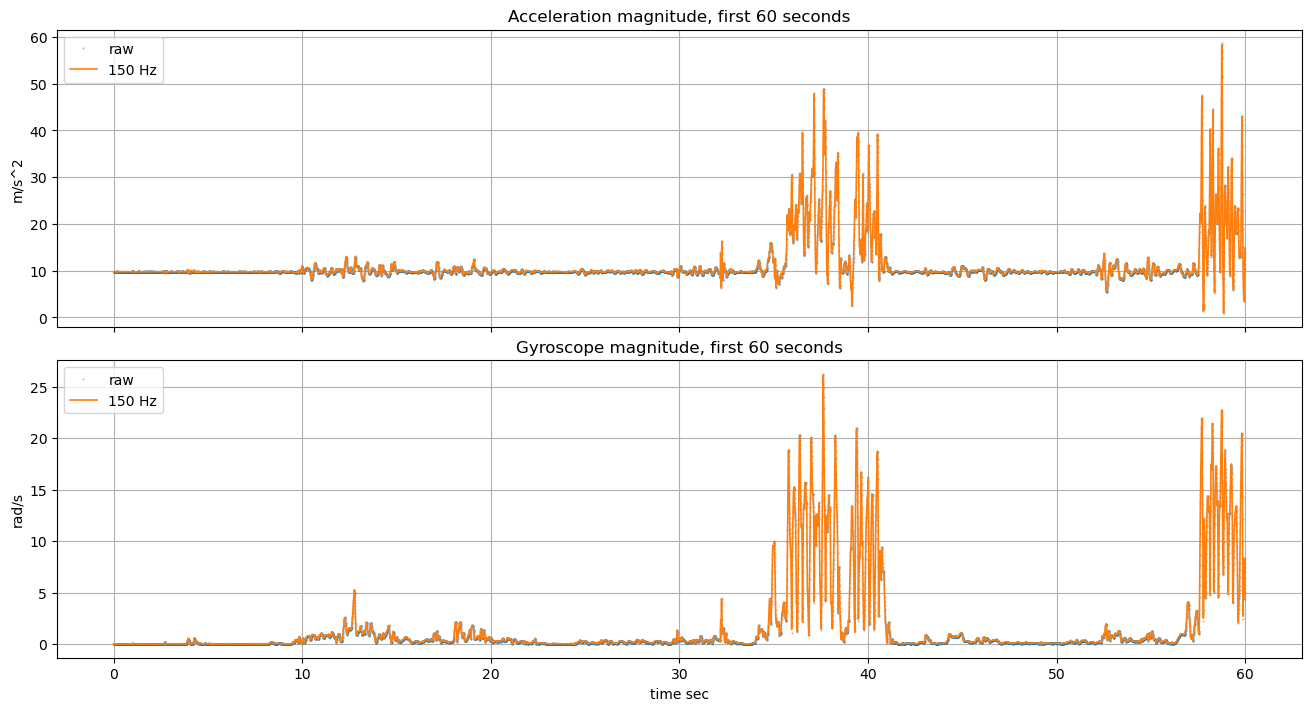

In [7]:
plot_end_ms = min(60_000.0, raw['time_ms'][-1], resampled['time_ms'][-1])
raw_mask = raw['time_ms'] <= plot_end_ms
resampled_mask = resampled['time_ms'] <= plot_end_ms

raw_acc_mag = np.linalg.norm(raw['acc'][raw_mask], axis=1)
resampled_acc_mag = np.linalg.norm(resampled['acc'][resampled_mask], axis=1)
raw_gyro_mag = np.linalg.norm(raw['gyro'][raw_mask], axis=1)
resampled_gyro_mag = np.linalg.norm(resampled['gyro'][resampled_mask], axis=1)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, constrained_layout=True)
axes[0].plot(raw['time_ms'][raw_mask] / 1000.0, raw_acc_mag, '.', markersize=1.2, alpha=0.35, label='raw')
axes[0].plot(resampled['time_ms'][resampled_mask] / 1000.0, resampled_acc_mag, linewidth=1.2, label='150 Hz')
axes[0].set_title('Acceleration magnitude, first 60 seconds')
axes[0].set_ylabel('m/s^2')
axes[0].legend()

axes[1].plot(raw['time_ms'][raw_mask] / 1000.0, raw_gyro_mag, '.', markersize=1.2, alpha=0.35, label='raw')
axes[1].plot(resampled['time_ms'][resampled_mask] / 1000.0, resampled_gyro_mag, linewidth=1.2, label='150 Hz')
axes[1].set_title('Gyroscope magnitude, first 60 seconds')
axes[1].set_xlabel('time sec')
axes[1].set_ylabel('rad/s')
axes[1].legend()

fig_path = OUTPUT_ROOT / 'figures' / 'resampled_magnitude.svg'
fig.savefig(fig_path)
print('saved:', fig_path)
plt.show()

## 5. Segment Validation

片段保存前需要满足两个条件：

1. 长度正好等于目标帧数。
2. 片段覆盖到的所有 raw 1-second bin 都满足 `raw frames >= 120`。

这里先统计当前样例文件能切出多少有效片段。

In [8]:
MODE_SPECS = {
    '10s': {
        'frames': int(math.ceil(TARGET_FREQ * 10.0)),
        'duration_sec': 10.0,
    },
    '1024f': {
        'frames': 1024,
        'duration_sec': 1024 / TARGET_FREQ,
    },
}


def target_quality_index(target_t: np.ndarray, bins: np.ndarray, valid: np.ndarray) -> np.ndarray:
    """Map each target sample to its raw-quality 1-second bin."""

    idx = np.searchsorted(bins, target_t, side='right') - 1
    return np.clip(idx, 0, len(valid) - 1)


def segment_is_valid(target_bin_idx: np.ndarray, valid_bins: np.ndarray, start: int, end: int) -> bool:
    """Return True if every raw-quality bin touched by the segment is valid."""

    segment_bins = np.unique(target_bin_idx[start:end])
    return bool(np.all(valid_bins[segment_bins]))


def valid_segments(target_t: np.ndarray, bins: np.ndarray, valid_bins: np.ndarray, frames: int) -> list[tuple[int, int]]:
    """Return non-overlapping valid segment frame ranges."""

    target_bin_idx = target_quality_index(target_t, bins, valid_bins)
    ranges = []
    for start in range(0, len(target_t) - frames + 1, frames):
        end = start + frames
        if segment_is_valid(target_bin_idx, valid_bins, start, end):
            ranges.append((start, end))
    return ranges

segments_by_mode = {}
for mode, spec in MODE_SPECS.items():
    ranges = valid_segments(resampled['time_ms'], bins, raw_valid, spec['frames'])
    segments_by_mode[mode] = ranges
    print(mode, 'frames:', spec['frames'], 'duration_sec:', spec['duration_sec'], 'valid_segments:', len(ranges))
    print(' first ranges:', ranges[:5])

10s frames: 1500 duration_sec: 10.0 valid_segments: 152
 first ranges: [(0, 1500), (1500, 3000), (3000, 4500), (4500, 6000), (6000, 7500)]
1024f frames: 1024 duration_sec: 6.826666666666667 valid_segments: 224
 first ranges: [(0, 1024), (1024, 2048), (2048, 3072), (3072, 4096), (4096, 5120)]


## 6. Save Sample NPZ And Manifest

这里保存每种 mode 的第一个有效片段到 `WaveHand/inspect_outputs/`。目录结构会模拟正式 processed root：

```text
WaveHand/inspect_outputs/sources/WaveHand/segments/{mode}/{device}/00000001.npz
WaveHand/inspect_outputs/sources/WaveHand/manifests/{device}_{mode}.jsonl
```

正式全量脚本确认后才会写入 `/Volumes/Felix_Backups/Processed2`。

In [9]:
def make_segment_arrays(resampled_data: dict, start: int, end: int) -> tuple[np.ndarray, np.ndarray]:
    """Create float32 [T, 4] acc/gyro arrays with segment-local time_ms."""

    local_t = resampled_data['time_ms'][start:end] - resampled_data['time_ms'][start]
    acc = np.column_stack([local_t, resampled_data['acc'][start:end]]).astype(np.float32)
    gyro = np.column_stack([local_t, resampled_data['gyro'][start:end]]).astype(np.float32)
    return acc, gyro


def save_sample_segment(mode: str, device: str, segment_range: tuple[int, int], segment_id: int = 1) -> dict:
    """Save one sample segment and append a source-manifest entry under OUTPUT_ROOT."""

    start, end = segment_range
    acc, gyro = make_segment_arrays(resampled, start, end)
    rel_dir = Path('sources') / SOURCE / 'segments' / mode / device / f'{segment_id:08d}.npz'
    npz_path = OUTPUT_ROOT / rel_dir
    npz_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez(npz_path, acc=acc, gyro=gyro)

    entry = {
        'dir': str(rel_dir),
        'src': SOURCE,
        'device': device,
        'freq': TARGET_FREQ,
        'mode': mode,
        'num_frames': int(acc.shape[0]),
        'duration_sec': MODE_SPECS[mode]['duration_sec'],
        'has_timestamp': True,
        'has_gyro': True,
        'label': {},
    }

    manifest_path = OUTPUT_ROOT / 'sources' / SOURCE / 'manifests' / f'{device}_{mode}.jsonl'
    manifest_path.parent.mkdir(parents=True, exist_ok=True)
    manifest_path.write_text(json.dumps(entry, ensure_ascii=False) + '\n', encoding='utf-8')
    return entry

sample_entries = []
for mode, ranges in segments_by_mode.items():
    if not ranges:
        print(mode, 'has no valid segment in this file')
        continue
    entry = save_sample_segment(mode, SAMPLE_DEVICE, ranges[0])
    sample_entries.append(entry)
    print(json.dumps(entry, ensure_ascii=False))

{"dir": "sources/WaveHand/segments/10s/ring/00000001.npz", "src": "WaveHand", "device": "ring", "freq": 150.0, "mode": "10s", "num_frames": 1500, "duration_sec": 10.0, "has_timestamp": true, "has_gyro": true, "label": {}}
{"dir": "sources/WaveHand/segments/1024f/ring/00000001.npz", "src": "WaveHand", "device": "ring", "freq": 150.0, "mode": "1024f", "num_frames": 1024, "duration_sec": 6.826666666666667, "has_timestamp": true, "has_gyro": true, "label": {}}


## 7. Reload And Inspect Saved Samples

重新读取刚刚保存的 `.npz`，确认最终数组符合 processed 规范。

In [10]:
for entry in sample_entries:
    npz_path = OUTPUT_ROOT / entry['dir']
    data = np.load(npz_path)
    acc = data['acc']
    gyro = data['gyro']
    print('\n', entry['mode'], npz_path)
    print(' acc shape/dtype:', acc.shape, acc.dtype)
    print(' gyro shape/dtype:', gyro.shape, gyro.dtype)
    print(' first time:', float(acc[0, 0]), 'last time:', float(acc[-1, 0]))
    print(' median dt:', float(np.median(np.diff(acc[:, 0]))))
    print(' acc magnitude median:', float(np.median(np.linalg.norm(acc[:, 1:4], axis=1))))
    print(' gyro magnitude median:', float(np.median(np.linalg.norm(gyro[:, 1:4], axis=1))))
    assert acc.dtype == np.float32
    assert gyro.dtype == np.float32
    assert acc.shape == (entry['num_frames'], 4)
    assert gyro.shape == (entry['num_frames'], 4)
    assert abs(float(acc[0, 0])) < 1e-6
    assert np.all(np.isfinite(acc))
    assert np.all(np.isfinite(gyro))
    assert np.allclose(acc[:, 0], gyro[:, 0])


 10s /Users/zixuanwang/Code/research/Dino_Data_Process/WaveHand/inspect_outputs/sources/WaveHand/segments/10s/ring/00000001.npz
 acc shape/dtype: (1500, 4) float32
 gyro shape/dtype: (1500, 4) float32
 first time: 0.0 last time: 9993.3330078125
 median dt: 6.666656494140625
 acc magnitude median: 9.777667999267578
 gyro magnitude median: 0.025050707161426544

 1024f /Users/zixuanwang/Code/research/Dino_Data_Process/WaveHand/inspect_outputs/sources/WaveHand/segments/1024f/ring/00000001.npz
 acc shape/dtype: (1024, 4) float32
 gyro shape/dtype: (1024, 4) float32
 first time: 0.0 last time: 6820.0
 median dt: 6.666656494140625
 acc magnitude median: 9.781822204589844
 gyro magnitude median: 0.022704817354679108


saved: /Users/zixuanwang/Code/research/Dino_Data_Process/WaveHand/inspect_outputs/figures/sample_segments.svg


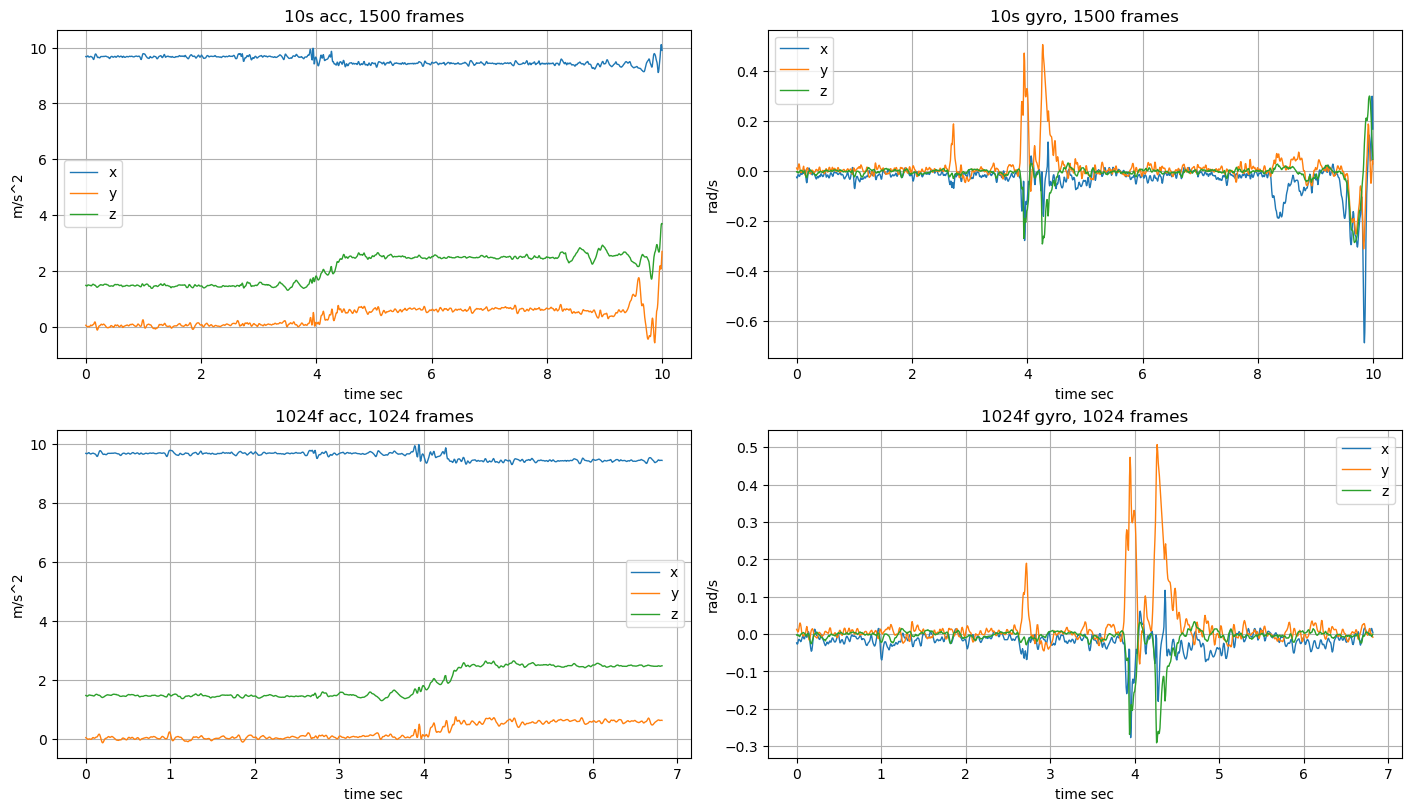

In [11]:
if sample_entries:
    fig, axes = plt.subplots(len(sample_entries), 2, figsize=(14, 4 * len(sample_entries)), constrained_layout=True)
    if len(sample_entries) == 1:
        axes = np.asarray([axes])

    for row, entry in enumerate(sample_entries):
        data = np.load(OUTPUT_ROOT / entry['dir'])
        acc = data['acc']
        gyro = data['gyro']
        t = acc[:, 0] / 1000.0

        for axis, label in enumerate(['x', 'y', 'z'], start=1):
            axes[row, 0].plot(t, acc[:, axis], linewidth=1.0, label=label)
        axes[row, 0].set_title(f"{entry['mode']} acc, {entry['num_frames']} frames")
        axes[row, 0].set_xlabel('time sec')
        axes[row, 0].set_ylabel('m/s^2')
        axes[row, 0].legend()

        for axis, label in enumerate(['x', 'y', 'z'], start=1):
            axes[row, 1].plot(t, gyro[:, axis], linewidth=1.0, label=label)
        axes[row, 1].set_title(f"{entry['mode']} gyro, {entry['num_frames']} frames")
        axes[row, 1].set_xlabel('time sec')
        axes[row, 1].set_ylabel('rad/s')
        axes[row, 1].legend()

    fig_path = OUTPUT_ROOT / 'figures' / 'sample_segments.svg'
    fig.savefig(fig_path)
    print('saved:', fig_path)
    plt.show()

## 8. Expected Full Script Behavior

如果这个 notebook 的结果符合预期，全量脚本可以按同一逻辑执行：

1. 遍历所有 group 的 `IMU_Ring` 和 `IMU_Wrist`。
2. 只读取 `calibrated_imu_*.csv`。
3. 对每个 CSV 做清洗、质量检查、150Hz 插值。
4. 生成 `10s` 和 `1024f` 两种不重叠片段。
5. 只保存片段级质量检查通过的片段。
6. 写入 `/Volumes/Felix_Backups/Processed2/sources/WaveHand/segments/...`。
7. 写入 source manifest：`ring_10s.jsonl`、`ring_1024f.jsonl`、`watch_10s.jsonl`、`watch_1024f.jsonl`。

本 notebook 不做全量写入，避免在确认前污染正式 processed 数据。